## This Notebook was made by Youssef Moataz, Mariam Mohamed, Zyad Mahgoub, Abdullah Hany, Reem Ahmed

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv('aug_train.csv')
test = pd.read_csv('aug_test.csv')

In [ ]:
train.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [ ]:
test.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 19158 entries, 0 to 19157
,Data columns (total 14 columns):
, #   Column                  Non-Null Count  Dtype  
,---  ------                  --------------  -----  
, 0   enrollee_id             19158 non-null  int64  
, 1   city                    19158 non-null  object 
, 2   city_development_index  19158 non-null  float64
, 3   gender                  14650 non-null  object 
, 4   relevent_experience     19158 non-null  object 
, 5   enrolled_university     18772 non-null  object 
, 6   education_level         18698 non-null  object 
, 7   major_discipline        16345 non-null  object 
, 8   experience              19093 non-null  object 
, 9   company_size            13220 non-null  object 
, 10  company_type            13018 non-null  object 
, 11  last_new_job            18735 non-null  object 
, 12  training_hours          19158 non-null  int64  
, 13  target                  19158 non-null  float64
,dtypes: float64(2), int6

## We can see that theres a lot of missing values in multiple columns that need to be handled.

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 2129 entries, 0 to 2128
,Data columns (total 13 columns):
, #   Column                  Non-Null Count  Dtype  
,---  ------                  --------------  -----  
, 0   enrollee_id             2129 non-null   int64  
, 1   city                    2129 non-null   object 
, 2   city_development_index  2129 non-null   float64
, 3   gender                  1621 non-null   object 
, 4   relevent_experience     2129 non-null   object 
, 5   enrolled_university     2098 non-null   object 
, 6   education_level         2077 non-null   object 
, 7   major_discipline        1817 non-null   object 
, 8   experience              2124 non-null   object 
, 9   company_size            1507 non-null   object 
, 10  company_type            1495 non-null   object 
, 11  last_new_job            2089 non-null   object 
, 12  training_hours          2129 non-null   int64  
,dtypes: float64(1), int64(2), object(10)
,memory usage: 216.4+ KB


In [ ]:
train.shape

(19158, 14)

In [ ]:
test.shape

(2129, 13)

In [ ]:
train_cols = set(train.columns)
test_cols = set(test.columns)

print("Columns only in train:", train_cols - test_cols)
print("Columns only in test:", test_cols - train_cols)

Columns only in train: {'target'}
,Columns only in test: set()


## The columns match but theres no target in test bacuase that would be cheating

In [ ]:
id_col = "enrollee_id"
target_col = "target"

feature_cols = [c for c in train.columns if c not in [id_col, target_col]]
feature_cols

['city',
 'city_development_index',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job',
 'training_hours']

In [ ]:
assert set(feature_cols) == set(test.columns) - {id_col}

## The columns in train and test are exactly the same afrer removing "enrollee_id" and "target"

## Now we split the data for train into features and target. and we label the test data as features only.

In [ ]:
X = train[feature_cols].copy()
y = train[target_col].copy()

X_test = test[feature_cols].copy()

In [ ]:
X.shape

(19158, 12)

In [ ]:
y.shape

(19158,)

In [ ]:
X_test.shape

(2129, 12)

## Now we need to split train into X_train, X_validate y_train and y_validate

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,          # 20% for validation
    stratify=y,             # keep same target ratio
    random_state=42
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((15326, 12), (3832, 12), (15326,), (3832,))

## Handling Missing Data and Obj columns

In [ ]:
missing = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percent": (X.isna().mean() * 100).round(2),
    "dtype": X.dtypes
}).sort_values("missing_percent", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_percent,dtype
company_type,6140,32.05,object
company_size,5938,30.99,object
gender,4508,23.53,object
major_discipline,2813,14.68,object
education_level,460,2.40,object
last_new_job,423,2.21,object
enrolled_university,386,2.01,object
experience,65,0.34,object


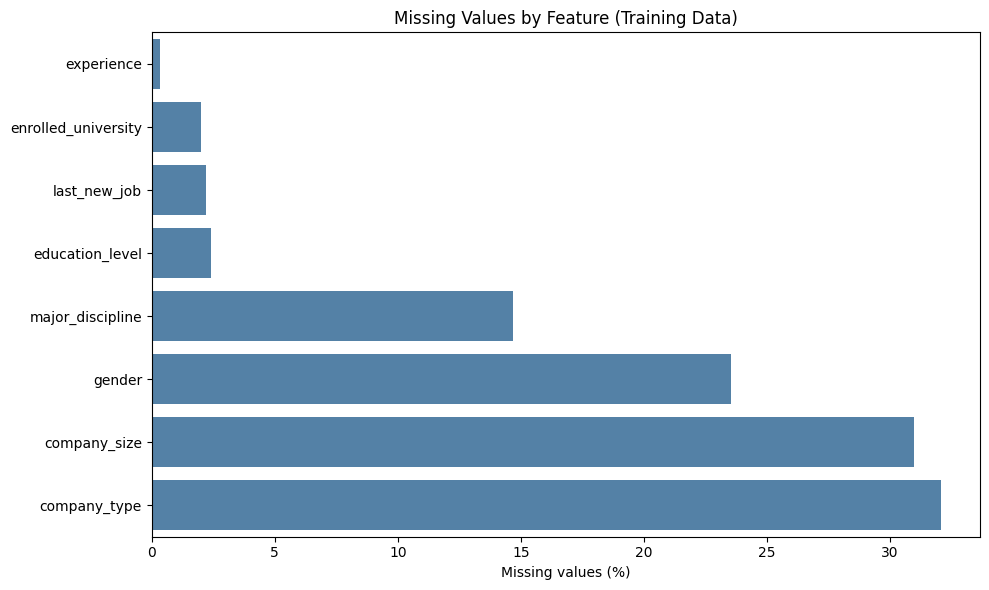

In [ ]:
plt.figure(figsize=(10, 6))
miss_plot = missing[missing["missing_count"] > 0].sort_values("missing_percent")

sns.barplot(
    x=miss_plot["missing_percent"],
    y=miss_plot.index,
    color="steelblue"
)
plt.title("Missing Values by Feature (Training Data)")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1865/1131528555.py:8: FutureWarning: 
,
,The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.
,
,  sns.barplot(


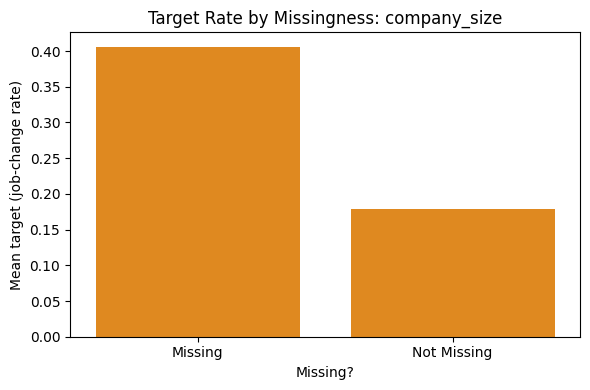

/tmp/ipykernel_1865/1131528555.py:8: FutureWarning: 
,
,The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.
,
,  sns.barplot(


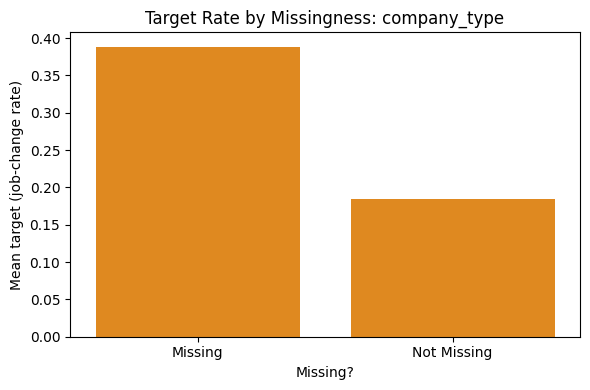

/tmp/ipykernel_1865/1131528555.py:8: FutureWarning: 
,
,The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.
,
,  sns.barplot(


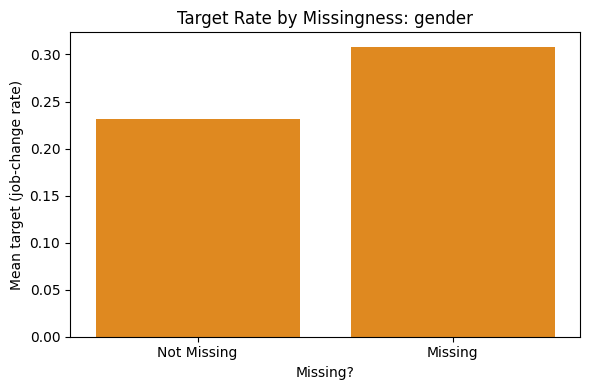

/tmp/ipykernel_1865/1131528555.py:8: FutureWarning: 
,
,The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.
,
,  sns.barplot(


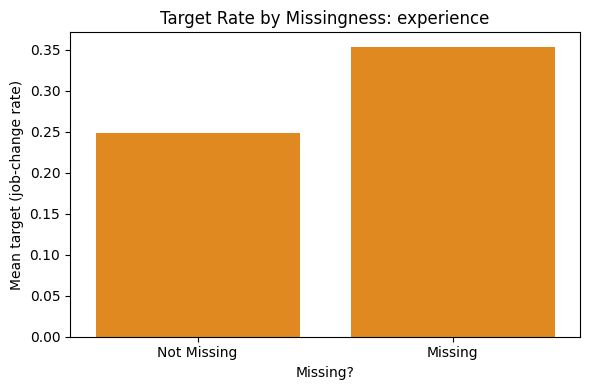

In [ ]:
cols_with_missing = [c for c in X.columns if X[c].isna().any()]

def plot_missing_vs_target(df, col):
    temp = df.copy()
    temp["is_missing"] = temp[col].isna().map({True: "Missing", False: "Not Missing"})

    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=temp,
        x="is_missing",
        y=target_col,
        ci=None,
        color="darkorange"
    )
    plt.title(f"Target Rate by Missingness: {col}")
    plt.xlabel("Missing?")
    plt.ylabel("Mean target (job-change rate)")
    plt.tight_layout()
    plt.show()

# Example for a few important columns
for col in ["company_size", "company_type", "gender", "experience"]:
    if col in cols_with_missing:
        plot_missing_vs_target(train, col)

In [ ]:
# If the bar heights differ a lot between “Missing” and “Not Missing”, missingness itself is informative.

Missingness (bar chart + missingness-vs-target charts)

company_type (32%), company_size (31%), gender (24%), major_discipline (15%) are heavily missing; education_level, last_new_job, enrolled_university, experience are only lightly missing (<2.5%). Critically, missingness is not random: rows missing company_size/company_type have a job-change rate of ~0.40 vs ~0.18 for non-missing — more than double. gender missing also shifts the rate (0.31 vs 0.23). That's a strong signal that "missing" itself is predictive, not just noise.

\
\
Critical missingness is not random: rows missing company_size/company_type have a job-change rate of ~0.40 vs ~0.18 for non-missing — more than double. gender missing also shifts the rate (0.31 vs 0.23). That's a strong signal that "missing" itself is predictive, not just noise.

In [ ]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['city_development_index', 'training_hours']

In [ ]:
X[numeric_cols].describe()

,city_development_index,training_hours
count,19158.000000,19158.000000
mean,0.828848,65.366896
std,0.123362,60.058462
min,0.448000,1.000000
25%,0.740000,23.000000
50%,0.903000,47.000000
75%,0.920000,88.000000
max,0.949000,336.000000


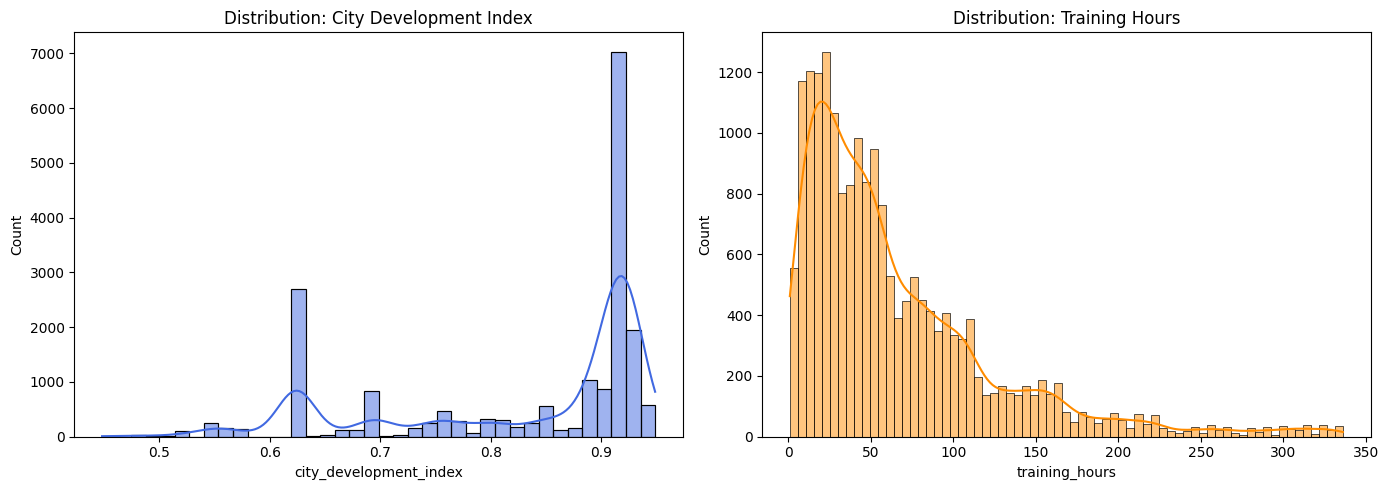

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=X,
    x="city_development_index",
    kde=True,
    ax=axes[0],
    color="royalblue"
)
axes[0].set_title("Distribution: City Development Index")

sns.histplot(
    data=X,
    x="training_hours",
    kde=True,
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Distribution: Training Hours")

plt.tight_layout()
plt.show()

city_development_index is bimodal/skewed left (clusters near 0.62–0.65 and a big spike near 0.92), not normal — so mean-based scaling assumptions are shaky, but no real outliers.
\
\
training_hours is heavily right-skewed with a long tail of "outliers" out past 200–300 in the boxplot. These aren't data errors, just a skewed real-world quantity.

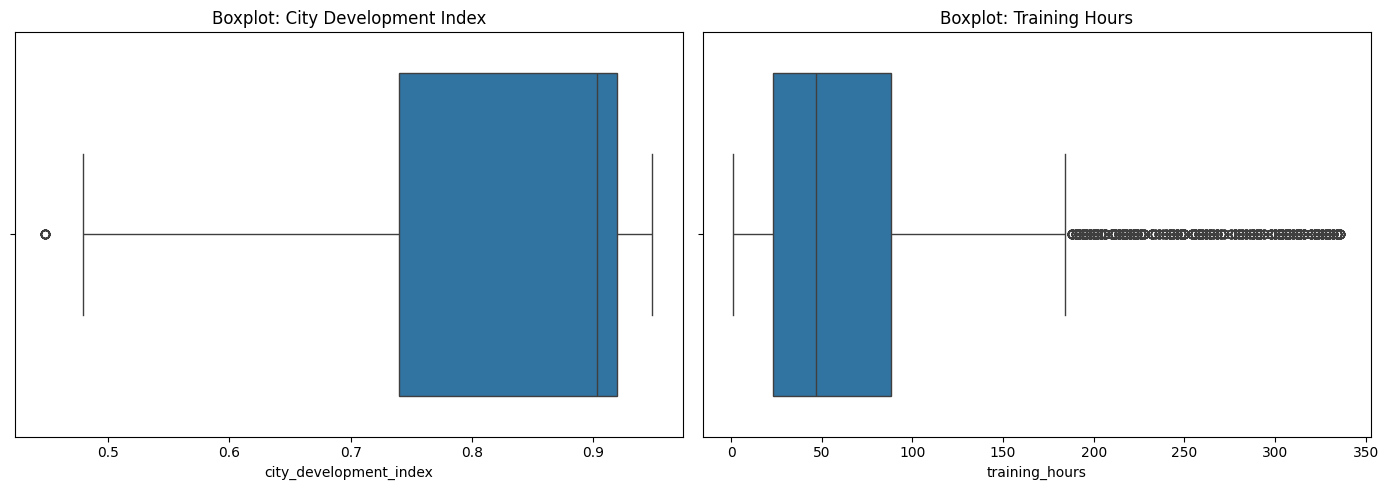

In [ ]:
#Boxplots to spot extreme values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=X, x="city_development_index", ax=axes[0])
axes[0].set_title("Boxplot: City Development Index")

sns.boxplot(data=X, x="training_hours", ax=axes[1])
axes[1].set_title("Boxplot: Training Hours")

plt.tight_layout()
plt.show()

## This shows theres tons of outliers in the "Training Hours" column

## Now lets do the catagorical features

In [ ]:
cat_cols = [
    "gender",
    "relevent_experience",
    "education_level",
    "company_size",
    "company_type",
    "experience",
    "last_new_job"
]

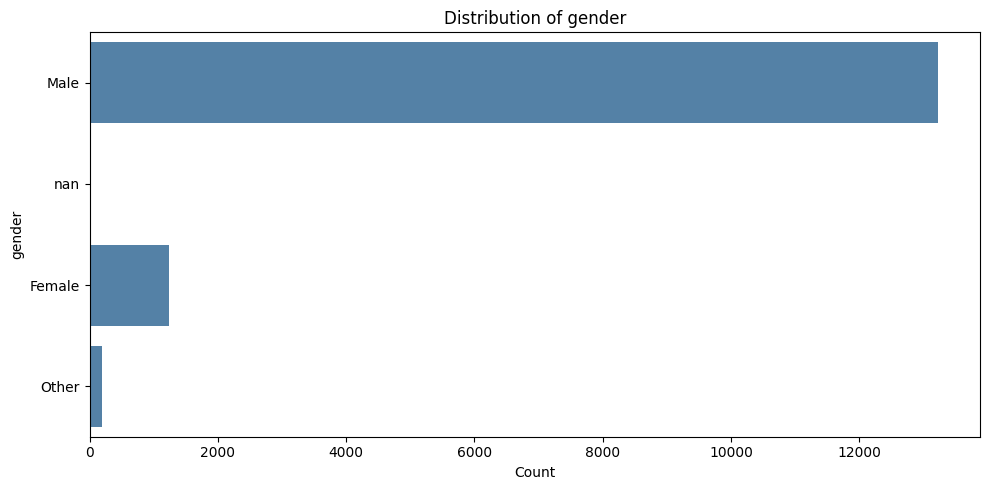

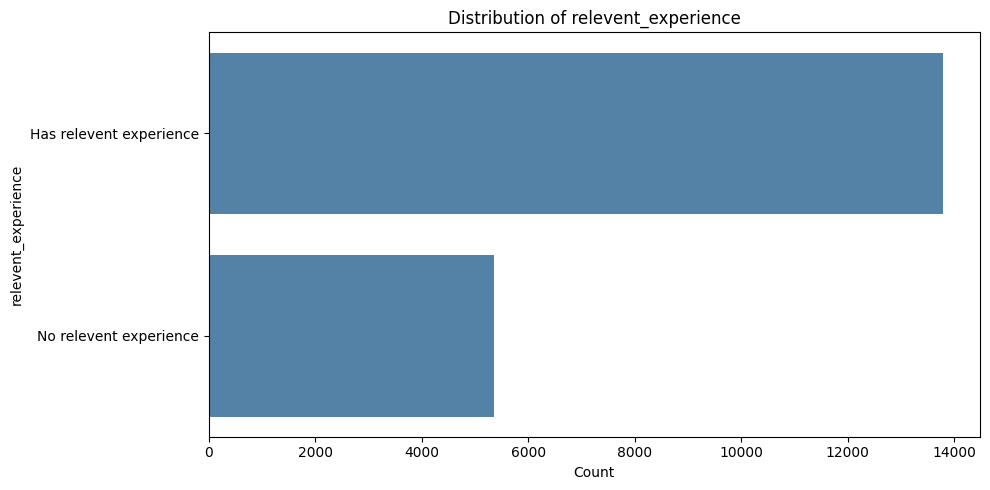

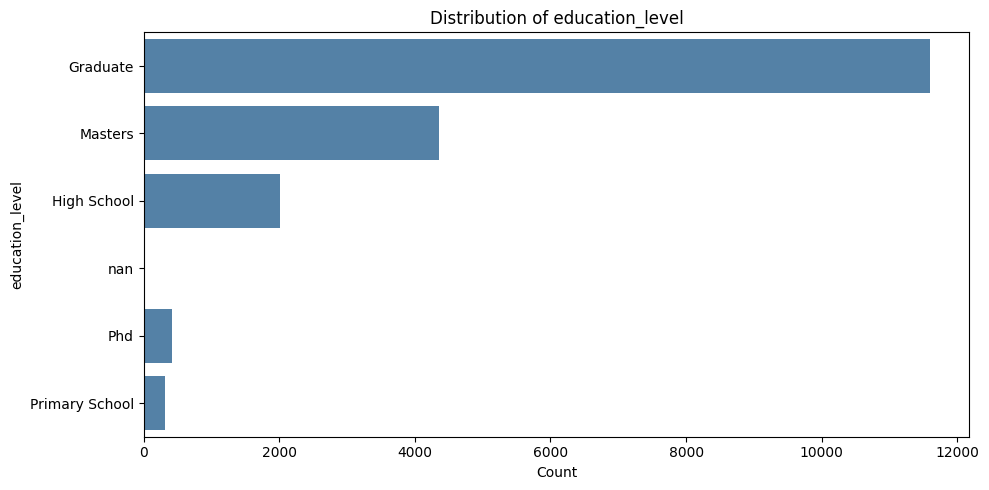

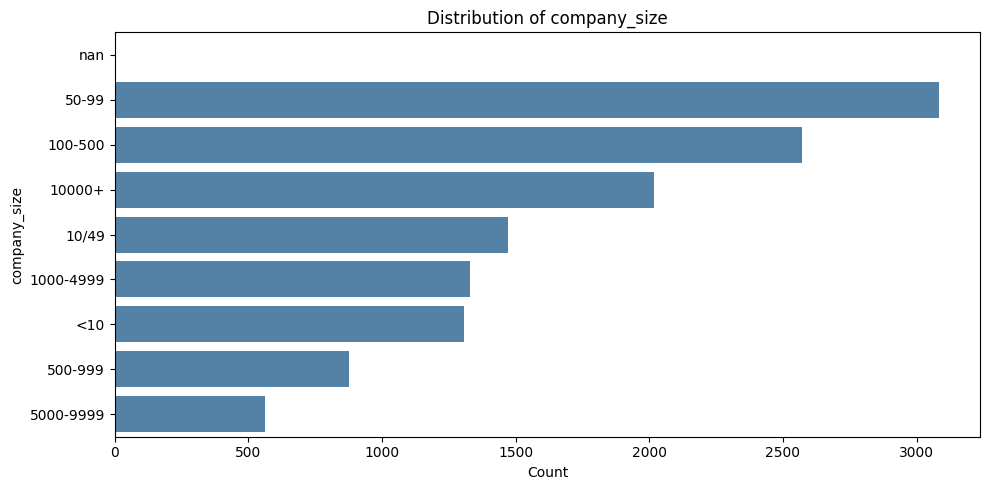

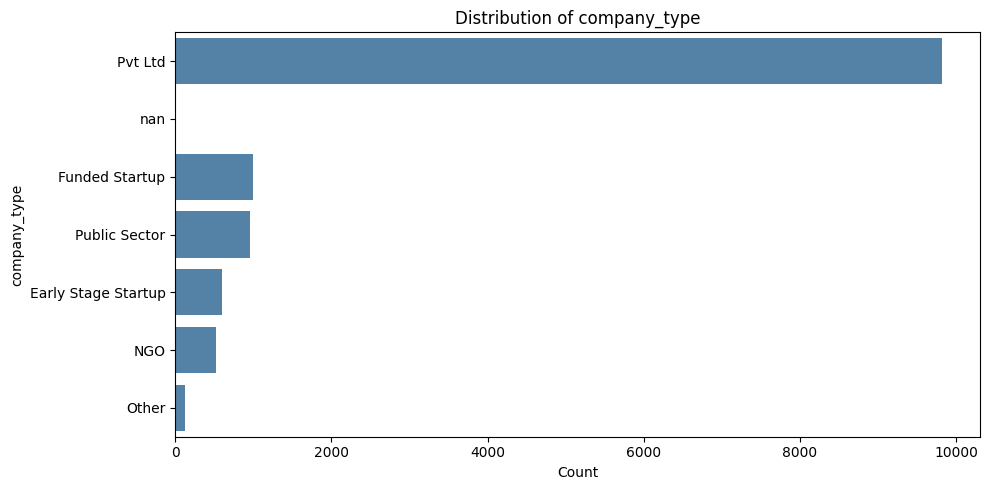

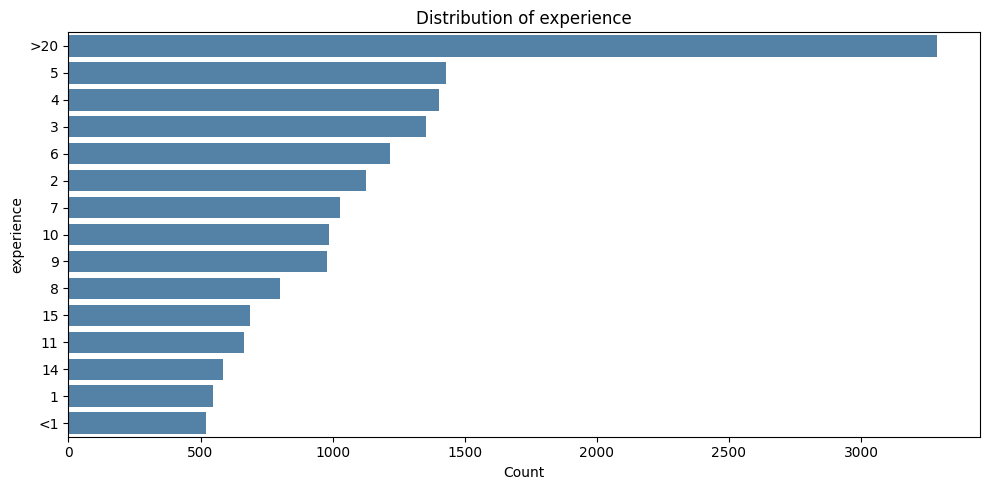

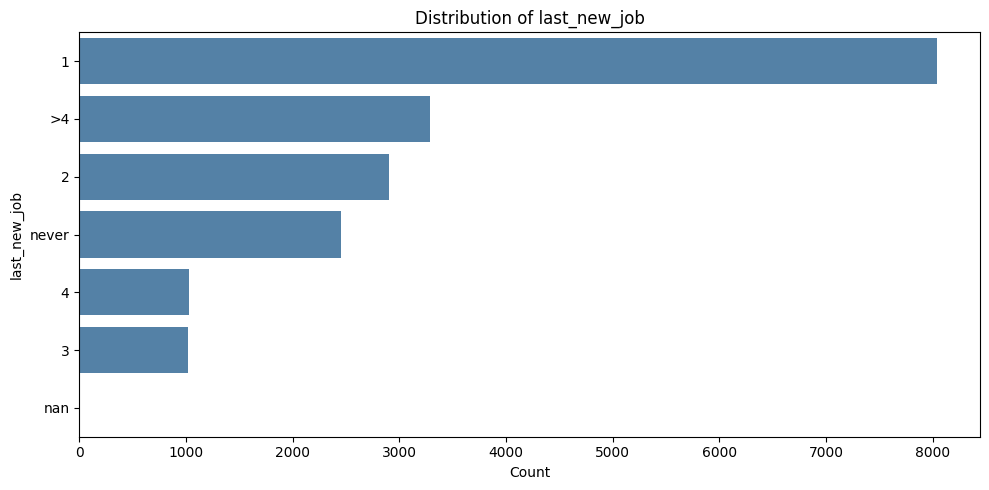

In [ ]:
def plot_top_categories(col, top_n=15):
    order = X[col].value_counts(dropna=False).head(top_n).index

    plt.figure(figsize=(10, 5))
    sns.countplot(
        y=col,
        data=X,
        order=order,
        color="steelblue"
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plot_top_categories(col)

## This shows: Dominant categories, Rare categories (might be noisy or have unstable target rates). How much “Missing” shows up if you later create it.

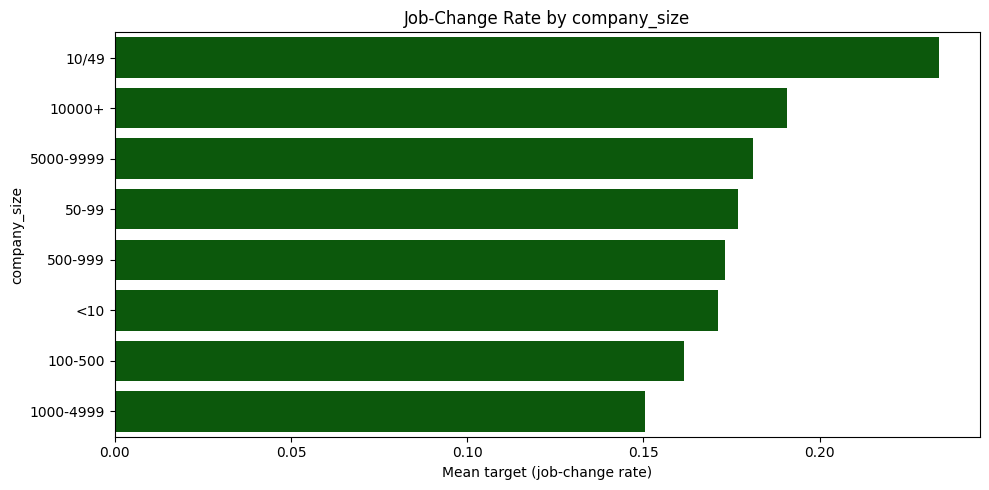

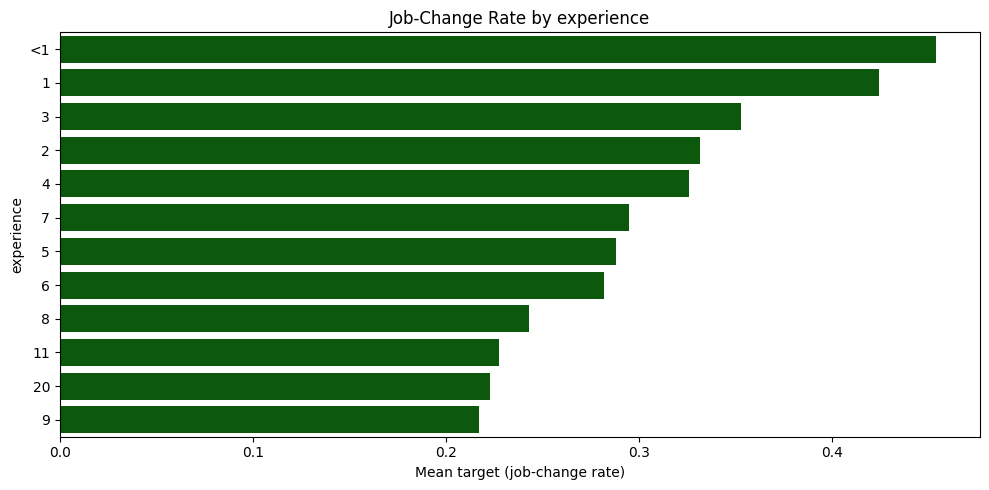

In [ ]:
def plot_target_rate_by_category(col, top_n=12, min_count=50):
    summary = (
        train.groupby(col, dropna=False)[target_col]
             .agg(["count", "mean"])
             .reset_index()
    )
    summary = summary[summary["count"] >= min_count]
    summary = summary.sort_values("mean", ascending=False).head(top_n)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=summary,
        x="mean",
        y=col,
        color="darkgreen"
    )
    plt.title(f"Job-Change Rate by {col}")
    plt.xlabel("Mean target (job-change rate)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

plot_target_rate_by_category("company_size", min_count=100)
plot_target_rate_by_category("experience", min_count=100)

In [ ]:
# Missing values are concentrated in company_size, company_type, gender, and major_discipline.
# training_hours is right-skewed with some very high values; these may be outliers but could also be real.
# Some categories in company_size and experience are rare and may need grouping or careful handling.
# Missingness in some columns appears associated with different target rates, so we should keep a ‘Missing’ category instead of deleting those rows.

## Before building the pipeline, we group columns by how they need to be treated. This grouping comes straight from the EDA: which columns are numeric vs categorical, which categoricals have a natural order, which are high-cardinality, and which have missingness that turned out to be informative rather than random.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# --- Column groups, based on the EDA above ---

# Numeric, needs log-transform for skew before scaling
log_numeric_cols = ["training_hours"]

# Numeric, scale only
plain_numeric_cols = ["city_development_index"]

# Binary categorical (2 levels, no real missingness)
binary_cols = ["relevent_experience"]

# High-missingness nominal categoricals -> impute "Missing" as its own category, then one-hot
nominal_missing_cols = ["gender", "major_discipline", "company_type", "enrolled_university"]

# Ordinal categoricals with a natural order
ordinal_cols = ["education_level", "experience", "company_size", "last_new_job"]

# High-cardinality nominal -> frequency encode instead of one-hot
high_card_cols = ["city"]

### For the ordinal columns, we define the category order explicitly rather than letting sklearn infer it alphabetically. experience and company_size have a real low-to-high ordering (e.g. "<1" should come before "1", "10/49" before "10000+"), and preserving that order lets models pick up on the ranking signal instead of treating these as unordered labels. "Missing" is added at the start of each order so it's treated consistently once we impute missing values with that label later.

In [ ]:
education_order   = ["Missing", "Primary School", "High School", "Graduate", "Masters", "Phd"]
experience_order  = ["Missing", "<1"] + [str(i) for i in range(1, 21)] + [">20"]
company_size_order = ["Missing", "<10", "10/49", "50-99", "100-500", "500-999",
                       "1000-4999", "5000-9999", "10000+"]
last_new_job_order = ["Missing", "never", "1", "2", "3", "4", ">4"]

ordinal_categories = [education_order, experience_order, company_size_order, last_new_job_order]

### city has too many unique values to one-hot encode without creating a huge, sparse feature set. Instead, we build a small custom transformer that replaces each city with how frequently it appeared in the training data. This keeps the column numeric and low-dimensional, and — importantly — the frequencies are learned only from X_train, so applying them to X_val/X_test doesn't leak information. Any city never seen during training just gets a frequency of 0.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.freq_maps_ = [X[col].value_counts(normalize=True).to_dict() for col in X.columns]
        self.feature_names_in_ = np.array(X.columns, dtype=object)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col, freq_map in zip(X.columns, self.freq_maps_):
            X[col] = X[col].map(freq_map).fillna(0.0)
        return X.values

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_

Here we build one small Pipeline per column group, matching the treatment each group needs:

training_hours gets a log transform first (to fix the right skew we saw in the histogram), then median imputation and scaling.

city_development_index just gets imputation and scaling (no skew-correction needed).
relevent_experience is a simple binary flag, one-hot encoded down to a single 0/1 column.

The nominal columns with heavy, informative missingness (gender major_discipline, company_type, enrolled_university) get missing values filled with the literal category "Missing" before one-hot encoding — so "this value wasn't reported" becomes its own explicit category the model can learn from, instead of being silently imputed away.

The ordinal columns use the category orders defined above, encoded as ordered integers.

city goes through the frequency encoder, then gets scaled like any other numeric feature.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
)

log_numeric_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
plain_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

nominal_missing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories,
                                handle_unknown="use_encoded_value",
                                unknown_value=-1))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("freq_encoder", FrequencyEncoder()),
    ("scaler", StandardScaler())
])

ColumnTransformer stitches all these sub-pipelines together into one object, applying each pipeline to its designated columns and concatenating the results into a single feature matrix. remainder="drop" is a safety net — any column not explicitly assigned to a group gets dropped rather than silently passed through unprocessed.

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_numeric_pipeline, log_numeric_cols),
        ("plain_num", plain_numeric_pipeline, plain_numeric_cols),
        ("binary", binary_pipeline, binary_cols),
        ("nominal_missing", nominal_missing_pipeline, nominal_missing_cols),
        ("ordinal", ordinal_pipeline, ordinal_cols),
        ("high_card", high_card_pipeline, high_card_cols),
    ],
    remainder="drop"
)

We fit the preprocessor only on X_train, then use .transform() (not .fit_transform()) on X_val and X_test. This is the step that prevents data leakage — the imputation values, scaling parameters, one-hot categories, and city frequencies are all learned exclusively from the training set, then applied unchanged to validation/test data.

In [ ]:
X_train_clean = preprocessor.fit_transform(X_train)
X_val_clean   = preprocessor.transform(X_val)
X_test_clean  = preprocessor.transform(X_test)

X_train_clean.shape, X_val_clean.shape, X_test_clean.shape

((15326, 30), (3832, 30), (2129, 30))

Since the output of the pipeline is a plain NumPy array, this step recovers the human-readable column names corresponding to each position — useful for feature importance, coefficient inspection, or just sanity-checking that the pipeline produced what you expect.

In [ ]:
feature_names = preprocessor.get_feature_names_out()
len(feature_names), feature_names[:15]

(30,
 array(['log_num__training_hours', 'plain_num__city_development_index',
        'binary__relevent_experience_No relevent experience',
        'nominal_missing__gender_Female', 'nominal_missing__gender_Male',
        'nominal_missing__gender_Missing', 'nominal_missing__gender_Other',
        'nominal_missing__major_discipline_Arts',
        'nominal_missing__major_discipline_Business Degree',
        'nominal_missing__major_discipline_Humanities',
        'nominal_missing__major_discipline_Missing',
        'nominal_missing__major_discipline_No Major',
        'nominal_missing__major_discipline_Other',
        'nominal_missing__major_discipline_STEM',
        'nominal_missing__company_type_Early Stage Startup'], dtype=object))

# Now We start modeling

In [ ]:
X_train_clean = preprocessor.fit_transform(X_train)
X_val_clean   = preprocessor.transform(X_val)
X_test_clean  = preprocessor.transform(X_test)

y_train, y_val

(17855    0.0
 17664    0.0
 13404    0.0
 13366    0.0
 15670    1.0
         ... 
 10398    0.0
 859      0.0
 10566    0.0
 3085     0.0
 3019     1.0
 Name: target, Length: 15326, dtype: float64,
 686      0.0
 1106     1.0
 8966     0.0
 7961     1.0
 5182     1.0
         ... 
 9055     1.0
 11207    0.0
 16790    0.0
 5575     0.0
 10387    0.0
 Name: target, Length: 3832, dtype: float64)

In [ ]:
import numpy as np

assert not np.isnan(X_train_clean).any()
assert not np.isnan(X_val_clean).any()
assert not np.isnan(X_test_clean).any()

X_train_clean.shape, X_val_clean.shape, X_test_clean.shape

((15326, 30), (3832, 30), (2129, 30))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_clean, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_val_pred = model.predict(X_val_clean)
y_val_prob = model.predict_proba(X_val_clean)[:, 1]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))


Validation Accuracy: 0.7800104384133612
,Confusion Matrix (Validation):
,[[2665  212]
, [ 631  324]]


In [ ]:
import pandas as pd

weights = pd.DataFrame({
    "Feature": feature_names,
    "Weight": model.coef_[0]
})

print(weights.sort_values(by="Weight", ascending=False))

                                              Feature    Weight
,16              nominal_missing__company_type_Missing  0.643133
,29                                       high_card__0  0.401841
,8   nominal_missing__major_discipline_Business Degree  0.271305
,2   binary__relevent_experience_No relevent experi...  0.248185
,13             nominal_missing__major_discipline_STEM  0.165127
,18                nominal_missing__company_type_Other  0.161974
,19        nominal_missing__company_type_Public Sector  0.157799
,11         nominal_missing__major_discipline_No Major  0.101212
,7              nominal_missing__major_discipline_Arts  0.091009
,21  nominal_missing__enrolled_university_Full time...  0.065888
,28                              ordinal__last_new_job  0.060467
,12            nominal_missing__major_discipline_Other  0.028358
,6                       nominal_missing__gender_Other  0.004560
,0                             log_num__training_hours -0.012801
,26                       

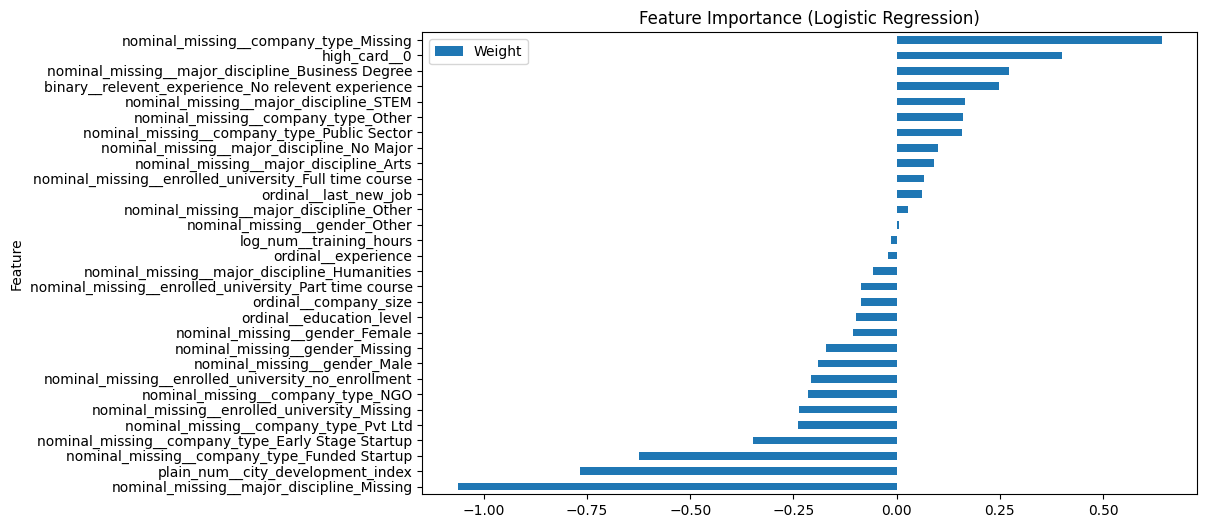

In [ ]:
import matplotlib.pyplot as plt

weights.sort_values(by="Weight").plot(
    x="Feature",
    y="Weight",
    kind="barh",
    figsize=(10,6)
)

plt.title("Feature Importance (Logistic Regression)")
plt.show()

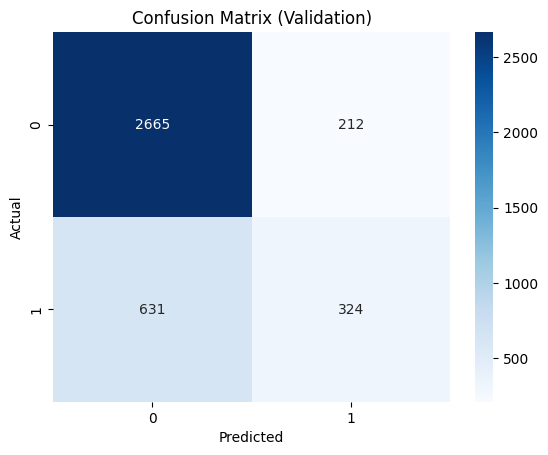

In [ ]:
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))


              precision    recall  f1-score   support
,
,         0.0       0.81      0.93      0.86      2877
,         1.0       0.60      0.34      0.43       955
,
,    accuracy                           0.78      3832
,   macro avg       0.71      0.63      0.65      3832
,weighted avg       0.76      0.78      0.76      3832
,


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_val_prob)
print("ROC-AUC (Validation):", roc_auc)


ROC-AUC (Validation): 0.8016565758034019


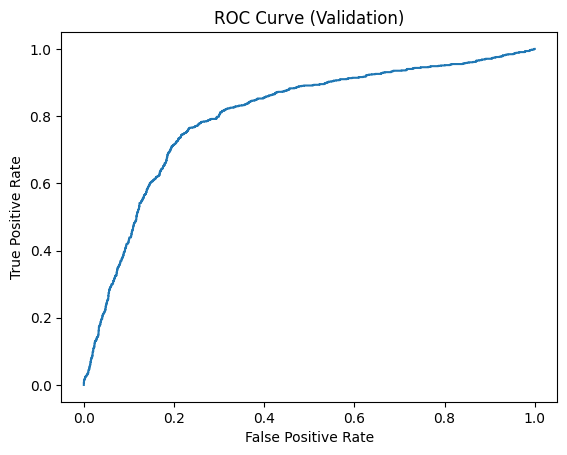

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, y_val_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))


Accuracy: 0.7800104384133612
,Precision: 0.6044776119402985
,Recall: 0.3392670157068063
,F1: 0.4346076458752515
,ROC-AUC: 0.8016565758034019


## Random Forest Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_clean, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
y_val_pred_rf = rf_model.predict(X_val_clean)
y_val_prob_rf = rf_model.predict_proba(X_val_clean)[:, 1]


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

def print_metrics(y_true, y_pred, y_prob, label):
    print(f"--- {label} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))
    print()

print_metrics(y_val, y_val_pred_rf, y_val_prob_rf, "Random Forest - Validation")


--- Random Forest - Validation ---
,Accuracy : 0.7951461377870563
,Precision: 0.5720338983050848
,Recall   : 0.7068062827225131
,F1 Score : 0.6323185011709602
,ROC-AUC  : 0.811028248957702
,


In [ ]:
print("Classification Report (Validation):")
print(classification_report(y_val, y_val_pred_rf))


Classification Report (Validation):
,              precision    recall  f1-score   support
,
,         0.0       0.89      0.82      0.86      2877
,         1.0       0.57      0.71      0.63       955
,
,    accuracy                           0.80      3832
,   macro avg       0.73      0.77      0.75      3832
,weighted avg       0.81      0.80      0.80      3832
,


In [ ]:
rf_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importances)

                                              Feature  Importance
,1                   plain_num__city_development_index    0.224685
,0                             log_num__training_hours    0.137345
,29                                       high_card__0    0.121632
,27                              ordinal__company_size    0.107889
,26                                ordinal__experience    0.106984
,28                              ordinal__last_new_job    0.055701
,16              nominal_missing__company_type_Missing    0.041339
,25                           ordinal__education_level    0.038091
,20              nominal_missing__company_type_Pvt Ltd    0.022162
,2   binary__relevent_experience_No relevent experi...    0.019493
,21  nominal_missing__enrolled_university_Full time...    0.014243
,24  nominal_missing__enrolled_university_no_enroll...    0.013450
,10          nominal_missing__major_discipline_Missing    0.013018
,13             nominal_missing__major_discipline_STEM    0.012

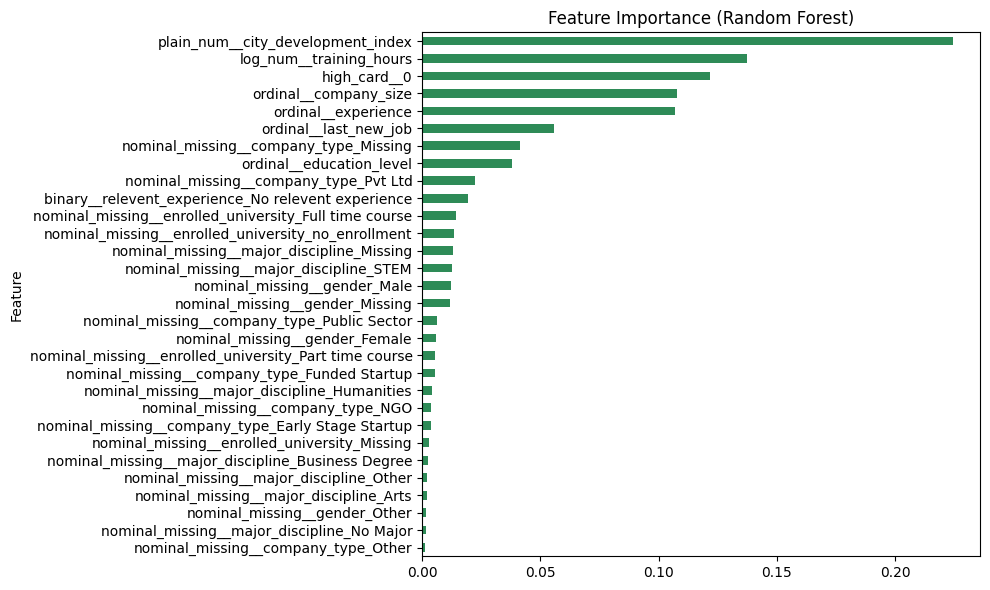

In [ ]:
plt.figure(figsize=(10,6))
rf_importances.sort_values("Importance").plot(
    x="Feature", y="Importance", kind="barh", ax=plt.gca(), legend=False, color="seagreen"
)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

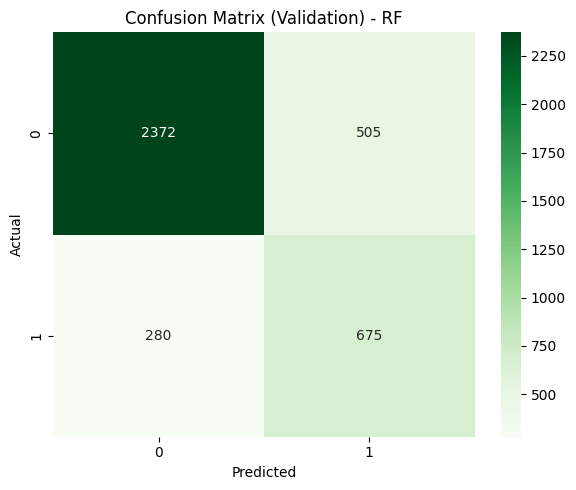

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_val, y_val_pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (Validation) - RF")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()


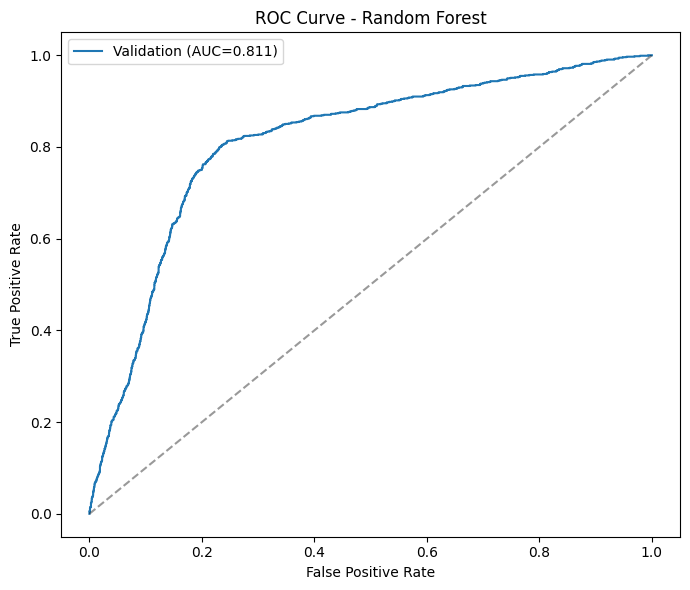

In [ ]:
from sklearn.metrics import roc_curve

fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_val, tpr_val, label=f"Validation (AUC={roc_auc_score(y_val, y_val_prob_rf):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


## XGBoost Model

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(
    X_train_clean,
    y_train,
    eval_set=[(X_val_clean, y_val)],
    verbose=False
)

y_pred = xgb_model.predict(X_val_clean)
y_pred_proba = xgb_model.predict_proba(X_val_clean)[:, 1]

print("=== Validation ROC-AUC Score ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba):.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_val, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_val, y_pred))

# X_test_clean comes from aug_test.csv, which has no target column -- these
# probabilities are for submission only and can't be scored against anything.
test_probabilities = xgb_model.predict_proba(X_test_clean)[:, 1]

submission = pd.DataFrame({
    'enrollee_id': test['enrollee_id'],
    'target': test_probabilities
})
submission.to_csv('xgb_submission.csv', index=False)


=== Validation ROC-AUC Score ===
,ROC-AUC: 0.8187
,
,=== Classification Report ===
,              precision    recall  f1-score   support
,
,         0.0       0.91      0.79      0.85      2877
,         1.0       0.56      0.78      0.65       955
,
,    accuracy                           0.79      3832
,   macro avg       0.74      0.79      0.75      3832
,weighted avg       0.83      0.79      0.80      3832
,
,=== Confusion Matrix ===
,[[2287  590]
, [ 214  741]]


## LightGBM

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:

ratio = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(
    X_train_clean,
    y_train,
    eval_set=[(X_val_clean, y_val)],
    eval_metric='auc'
)

y_pred_lgbm = lgbm_model.predict(X_val_clean)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_val_clean)[:, 1]

print("=== Validation ROC-AUC Score ===")
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_lgbm):.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_val, y_pred_lgbm))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_val, y_pred_lgbm))

# submission-only predictions, aug_test.csv has no labels to score against
test_probabilities_lgbm = lgbm_model.predict_proba(X_test_clean)[:, 1]

submission_lgbm = pd.DataFrame({
    'enrollee_id': test['enrollee_id'],
    'target': test_probabilities_lgbm
})
submission_lgbm.to_csv('lgbm_submission.csv', index=False)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
,  warnings.warn(
,/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
,  warnings.warn(


=== Validation ROC-AUC Score ===
,ROC-AUC: 0.8229
,
,=== Classification Report ===
,              precision    recall  f1-score   support
,
,         0.0       0.92      0.79      0.85      2877
,         1.0       0.56      0.78      0.65       955
,
,    accuracy                           0.79      3832
,   macro avg       0.74      0.79      0.75      3832
,weighted avg       0.83      0.79      0.80      3832
,
,=== Confusion Matrix ===
,[[2286  591]
, [ 209  746]]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
,  warnings.warn(


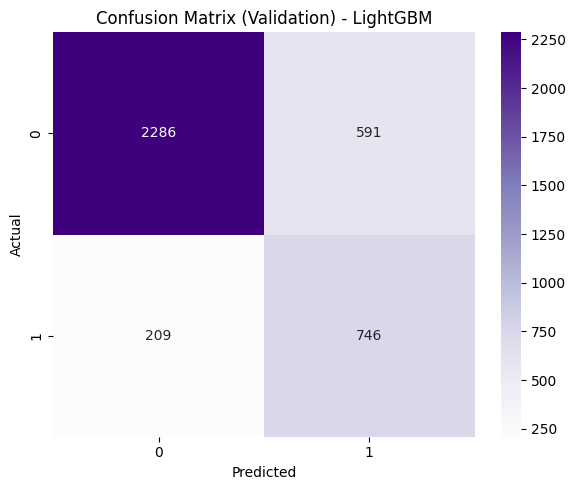

In [ ]:
cm_lgbm = confusion_matrix(y_val, y_pred_lgbm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix (Validation) - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

                                              Feature  Importance
,0                             log_num__training_hours        1044
,26                                ordinal__experience         585
,1                   plain_num__city_development_index         554
,29                                       high_card__0         540
,27                              ordinal__company_size         401
,28                              ordinal__last_new_job         334
,25                           ordinal__education_level         272
,2   binary__relevent_experience_No relevent experi...          94
,16              nominal_missing__company_type_Missing          90
,4                        nominal_missing__gender_Male          80
,5                     nominal_missing__gender_Missing          75
,13             nominal_missing__major_discipline_STEM          75
,21  nominal_missing__enrolled_university_Full time...          73
,20              nominal_missing__company_type_Pvt Ltd         

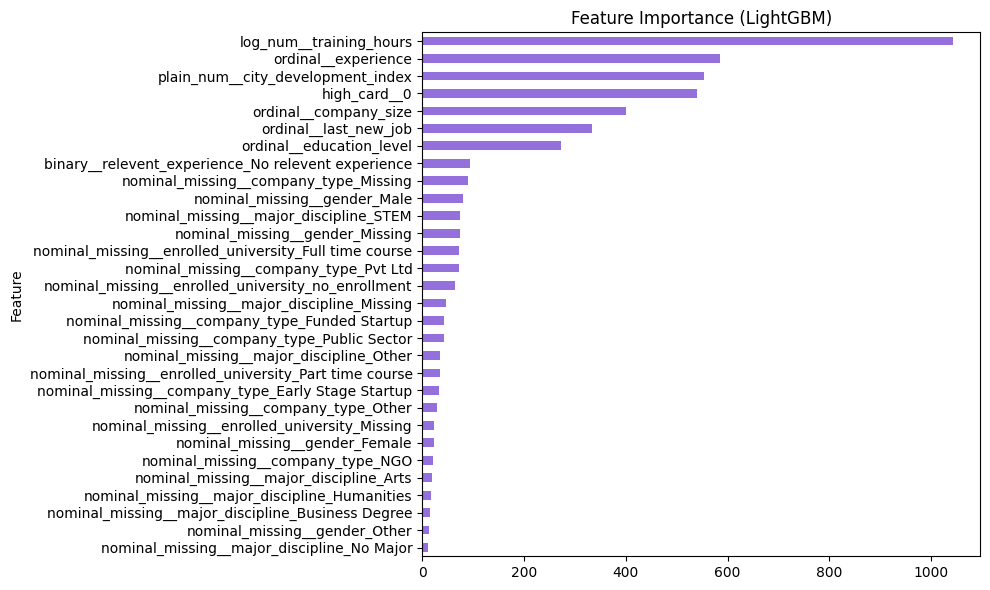

In [ ]:
lgbm_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(lgbm_importances)

plt.figure(figsize=(10,6))
lgbm_importances.sort_values("Importance").plot(
    x="Feature", y="Importance", kind="barh", ax=plt.gca(), legend=False, color="mediumpurple"
)
plt.title("Feature Importance (LightGBM)")
plt.tight_layout()
plt.show()

## CatBoost

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    class_weights=[1, pos_weight],
    random_state=42,
    eval_metric="AUC",
    verbose=False
)
cat_model.fit(X_train_clean, y_train, eval_set=(X_val_clean, y_val))

y_val_pred_cb = cat_model.predict(X_val_clean)
y_val_prob_cb = cat_model.predict_proba(X_val_clean)[:, 1]

print_metrics(y_val, y_val_pred_cb, y_val_prob_cb, "CatBoost - Validation")

print("Classification Report (Validation):")
print(classification_report(y_val, y_val_pred_cb))

,  Downloading catboost-1.2.10-cp313-cp313-manylinux2014_x86_64.whl.metadata (1.4 kB)
,Requirement already satisfied: graphviz in /usr/local/lib/python3.13/dist-packages (from catboost) (0.21)
,Requirement already satisfied: matplotlib in /usr/local/lib/python3.13/dist-packages (from catboost) (3.10.0)
,Requirement already satisfied: numpy<3.0,>=1.16.0 in /usr/local/lib/python3.13/dist-packages (from catboost) (2.1.3)
,Requirement already satisfied: pandas<4.0,>=0.24 in /usr/local/lib/python3.13/dist-packages (from catboost) (2.2.3)
,Requirement already satisfied: scipy in /usr/local/lib/python3.13/dist-packages (from catboost) (1.16.3)
,Requirement already satisfied: plotly in /usr/local/lib/python3.13/dist-packages (from catboost) (5.24.1)
,Requirement already satisfied: six in /usr/local/lib/python3.13/dist-packages (from catboost) (1.17.0)
,Requirement already satisfied: python-dateutil>=2.8.2 in /usr/local/lib/python3.13/dist-packages (from pandas<4.0,>=0.24->catboost) (2.9.0.post

                                              Feature  Importance
,1                   plain_num__city_development_index   27.046663
,27                              ordinal__company_size   17.592255
,29                                       high_card__0    8.573415
,25                           ordinal__education_level    7.025967
,0                             log_num__training_hours    6.238953
,26                                ordinal__experience    6.108258
,28                              ordinal__last_new_job    5.594601
,16              nominal_missing__company_type_Missing    4.520415
,2   binary__relevent_experience_No relevent experi...    3.793170
,10          nominal_missing__major_discipline_Missing    2.000823
,20              nominal_missing__company_type_Pvt Ltd    1.138802
,21  nominal_missing__enrolled_university_Full time...    1.097066
,5                     nominal_missing__gender_Missing    1.015979
,24  nominal_missing__enrolled_university_no_enroll...    0.974

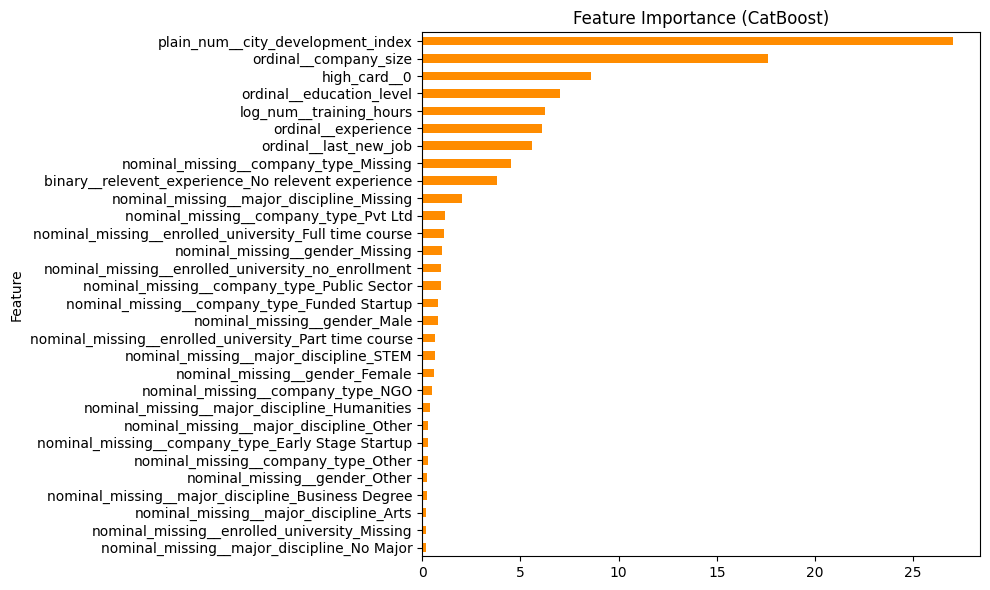

In [ ]:
cb_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": cat_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print(cb_importances)

plt.figure(figsize=(10,6))
cb_importances.sort_values("Importance").plot(
    x="Feature", y="Importance", kind="barh", ax=plt.gca(), legend=False, color="darkorange"
)
plt.title("Feature Importance (CatBoost)")
plt.tight_layout()
plt.show()

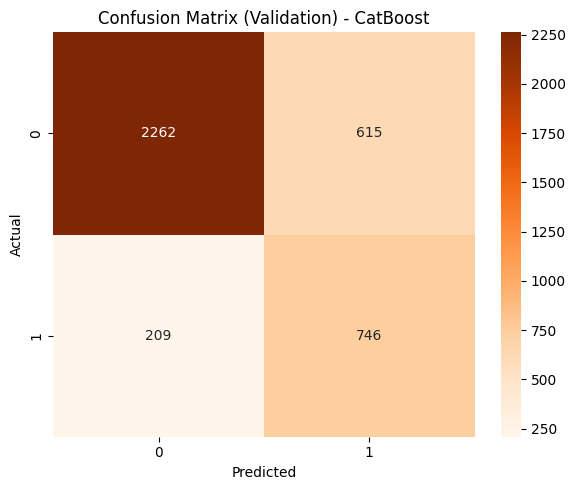

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_val, y_val_pred_cb), annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix (Validation) - CatBoost")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

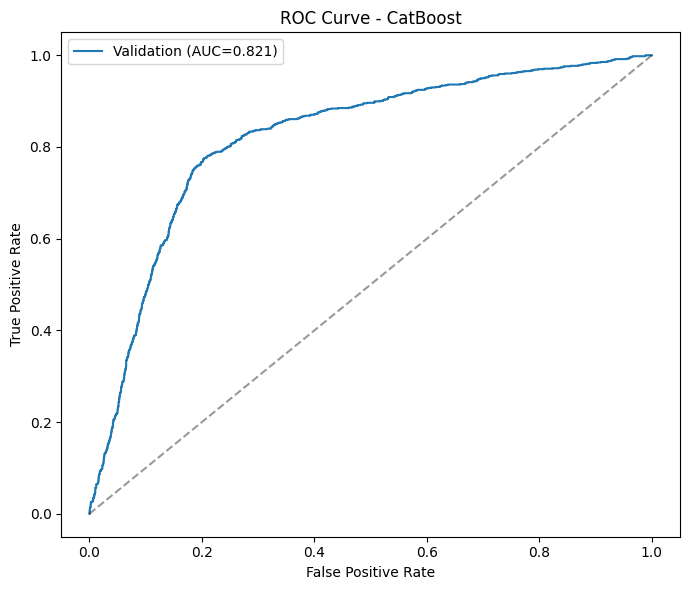

In [ ]:
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob_cb)
plt.figure(figsize=(7,6))
plt.plot(fpr_val, tpr_val, label=f"Validation (AUC={roc_auc_score(y_val, y_val_prob_cb):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.tight_layout()
plt.show()

## Now lets compare between the models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_val_results = {
    "Logistic Regression": (y_val_pred, y_val_prob),
    "Random Forest":       (y_val_pred_rf, y_val_prob_rf),
    "XGBoost":             (y_pred, y_pred_proba),
    "LightGBM":            (y_pred_lgbm, y_pred_proba_lgbm),
    "CatBoost":            (y_val_pred_cb, y_val_prob_cb),
}

rows = []
for name, (pred, prob) in model_val_results.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "ROC-AUC": roc_auc_score(y_val, prob),
    })

comparison_val_df = pd.DataFrame(rows).set_index("Model")
comparison_val_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.780010,0.604478,0.339267,0.434608,0.801657
Random Forest,0.795146,0.572034,0.706806,0.632319,0.811028
XGBoost,0.790188,0.556724,0.775916,0.648294,0.818734
LightGBM,0.791232,0.557966,0.781152,0.650960,0.822930
CatBoost,0.784969,0.548126,0.781152,0.644214,0.820592


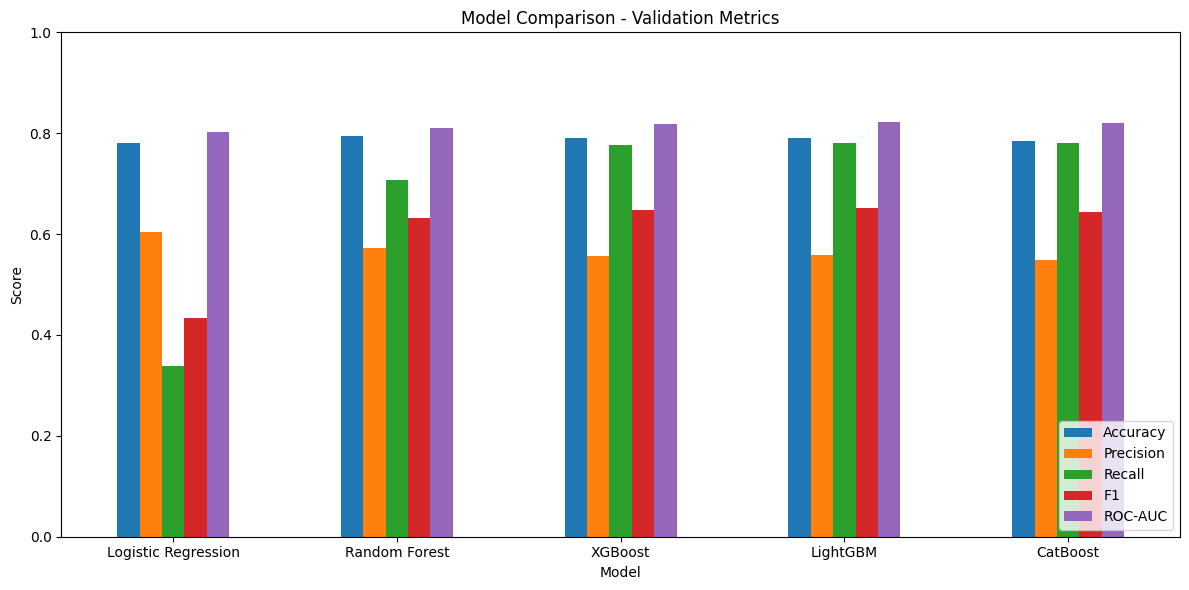

In [ ]:
comparison_val_df.plot(kind="bar", figsize=(12,6))
plt.title("Model Comparison - Validation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## New we try the test dataset

In [ ]:
y_test_true = np.load('/content/jobchange_test_target_values.npy')

print(y_test_true.shape, len(test))
assert len(y_test_true) == len(test), "answer key length doesn't match aug_test.csv rows"
print("Test positive rate:", y_test_true.mean(), " | Train positive rate:", y_train.mean())

(2129,) 2129
,Test positive rate: 0.2705495537811179  | Train positive rate: 0.24938013832702596


In [ ]:
test_pred_lr = model.predict(X_test_clean)
test_prob_lr = model.predict_proba(X_test_clean)[:, 1]

test_pred_rf = rf_model.predict(X_test_clean)
test_prob_rf = rf_model.predict_proba(X_test_clean)[:, 1]

test_pred_xgb = xgb_model.predict(X_test_clean)
test_prob_xgb = xgb_model.predict_proba(X_test_clean)[:, 1]

test_pred_lgbm = lgbm_model.predict(X_test_clean)
test_prob_lgbm = lgbm_model.predict_proba(X_test_clean)[:, 1]

test_pred_cb = cat_model.predict(X_test_clean)
test_prob_cb = cat_model.predict_proba(X_test_clean)[:, 1]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
,  warnings.warn(
,/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
,  warnings.warn(


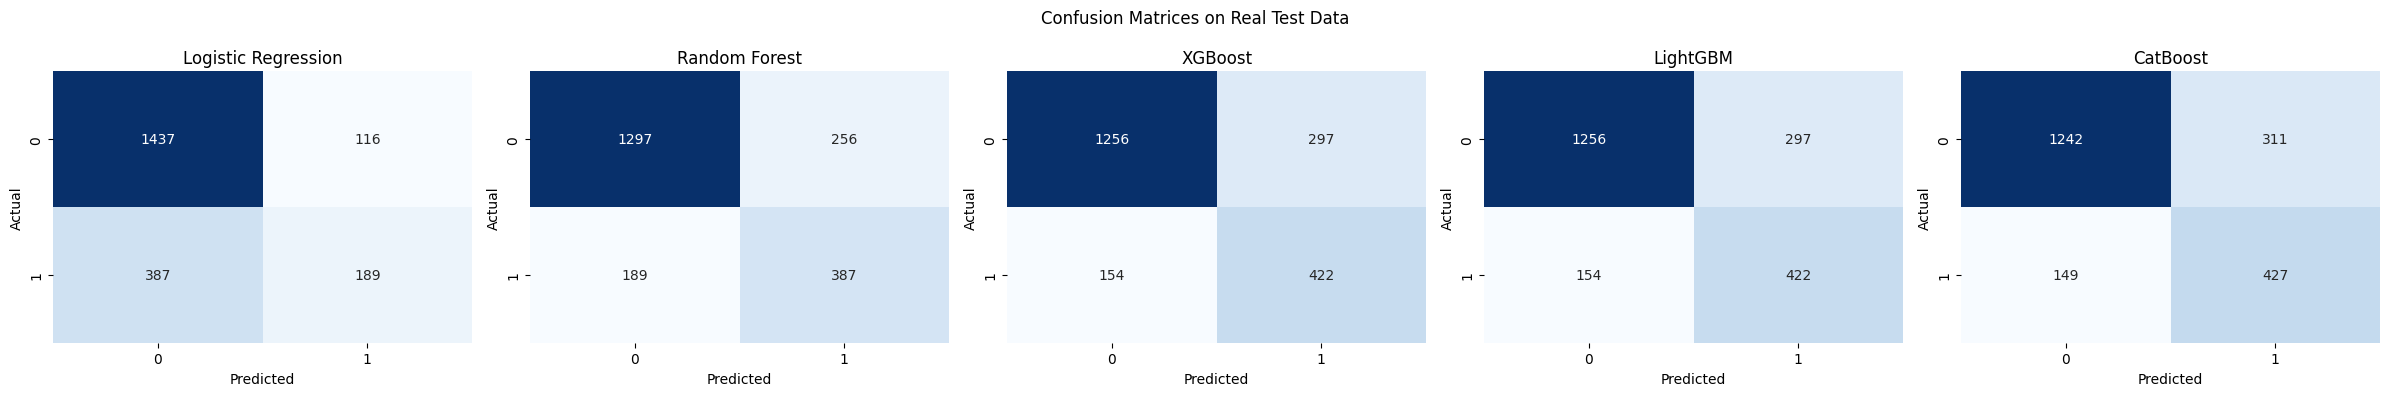

In [ ]:
test_models = {
    "Logistic Regression": test_pred_lr,
    "Random Forest":       test_pred_rf,
    "XGBoost":             test_pred_xgb,
    "LightGBM":            test_pred_lgbm,
    "CatBoost":            test_pred_cb,
}

fig, axes = plt.subplots(1, 5, figsize=(24, 4))

for ax, (name, pred) in zip(axes, test_models.items()):
    cm = confusion_matrix(y_test_true, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices on Real Test Data")
plt.tight_layout()
plt.show()

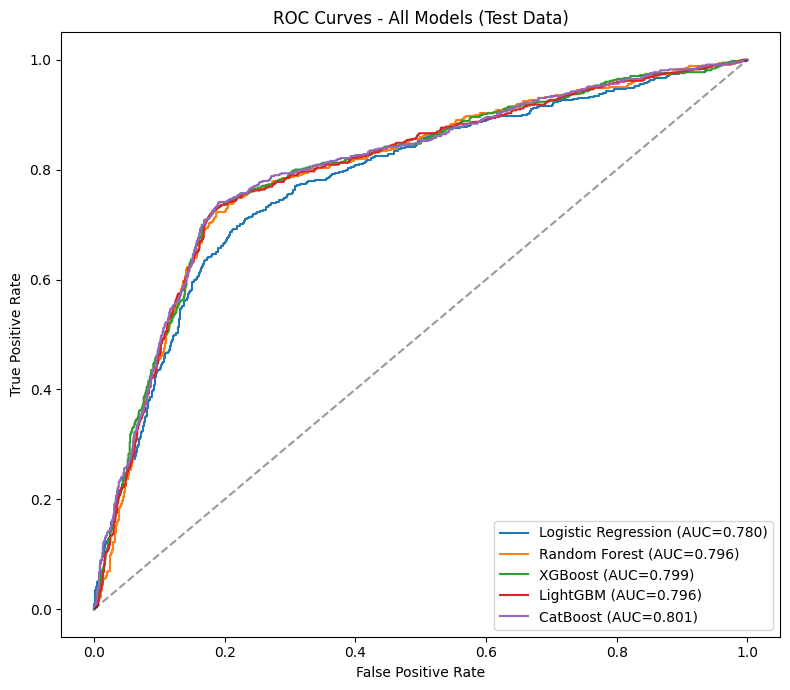

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

test_probs = {
    "Logistic Regression": test_prob_lr,
    "Random Forest":       test_prob_rf,
    "XGBoost":             test_prob_xgb,
    "LightGBM":            test_prob_lgbm,
    "CatBoost":            test_prob_cb,
}

plt.figure(figsize=(8, 7))

for name, prob in test_probs.items():
    fpr, tpr, _ = roc_curve(y_test_true, prob)
    auc = roc_auc_score(y_test_true, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models (Test Data)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
model_test_results = {
    "Logistic Regression": (test_pred_lr, test_prob_lr),
    "Random Forest":       (test_pred_rf, test_prob_rf),
    "XGBoost":             (test_pred_xgb, test_prob_xgb),
    "LightGBM":            (test_pred_lgbm, test_prob_lgbm),
    "CatBoost":            (test_pred_cb, test_prob_cb),
}

rows = []
for name, (pred, prob) in model_test_results.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_true, pred),
        "Precision": precision_score(y_test_true, pred),
        "Recall": recall_score(y_test_true, pred),
        "F1": f1_score(y_test_true, pred),
        "ROC-AUC": roc_auc_score(y_test_true, prob),
    })

comparison_test_df = pd.DataFrame(rows).set_index("Model")
comparison_test_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.763739,0.619672,0.328125,0.429058,0.780286
Random Forest,0.790982,0.601866,0.671875,0.634947,0.795526
XGBoost,0.788163,0.586926,0.732639,0.651737,0.798618
LightGBM,0.788163,0.586926,0.732639,0.651737,0.795807
CatBoost,0.783936,0.578591,0.741319,0.649924,0.800561


In [ ]:
full_comparison = pd.concat(
    {"Train/Validation": comparison_val_df, "Test": comparison_test_df},
    axis=1
)
full_comparison

Train/Validation                                          \
                            Accuracy Precision    Recall        F1   ROC-AUC   
Model                                                                          
Logistic Regression         0.780010  0.604478  0.339267  0.434608  0.801657   
Random Forest               0.795146  0.572034  0.706806  0.632319  0.811028   
XGBoost                     0.790188  0.556724  0.775916  0.648294  0.818734   
LightGBM                    0.791232  0.557966  0.781152  0.650960  0.822930   
CatBoost                    0.784969  0.548126  0.781152  0.644214  0.820592   

                         Test                                          
                     Accuracy Precision    Recall        F1   ROC-AUC  
Model                                                                  
Logistic Regression  0.763739  0.619672  0.328125  0.429058  0.780286  
Random Forest        0.790982  0.601866  0.671875  0.634947  0.795526  
XGBoost              0.788163  0.586926  0.732639  0.651737  0.798618  
LightGBM             0.788163  0.586926  0.732639  0.651737  0.795807  
CatBoost             0.783936  0.578591  0.741319  0.649924  0.800561

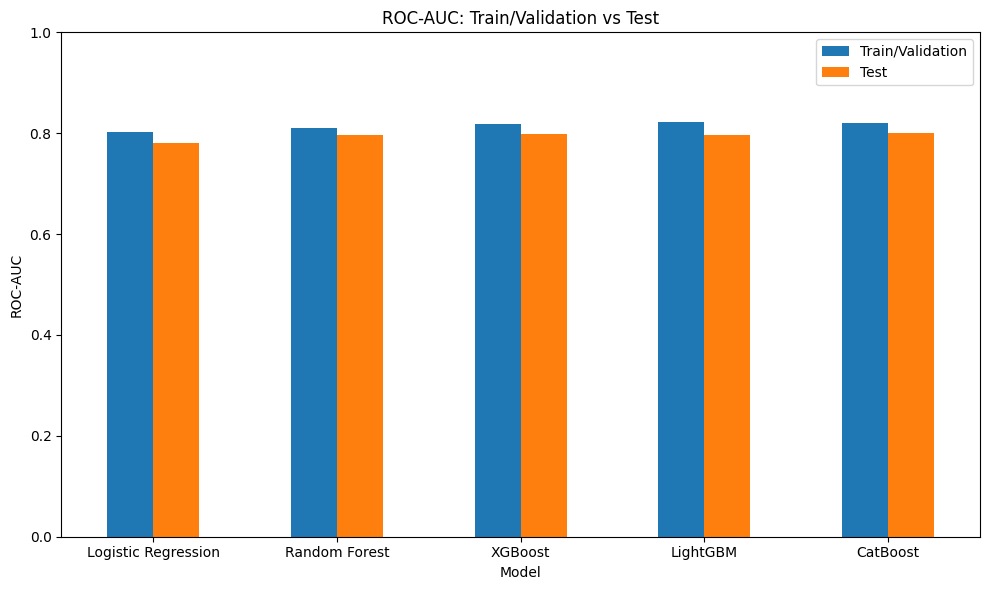

In [ ]:
combined_auc = pd.DataFrame({
    "Train/Validation": comparison_val_df["ROC-AUC"],
    "Test": comparison_test_df["ROC-AUC"]
})

combined_auc.plot(kind="bar", figsize=(10,6))
plt.title("ROC-AUC: Train/Validation vs Test")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

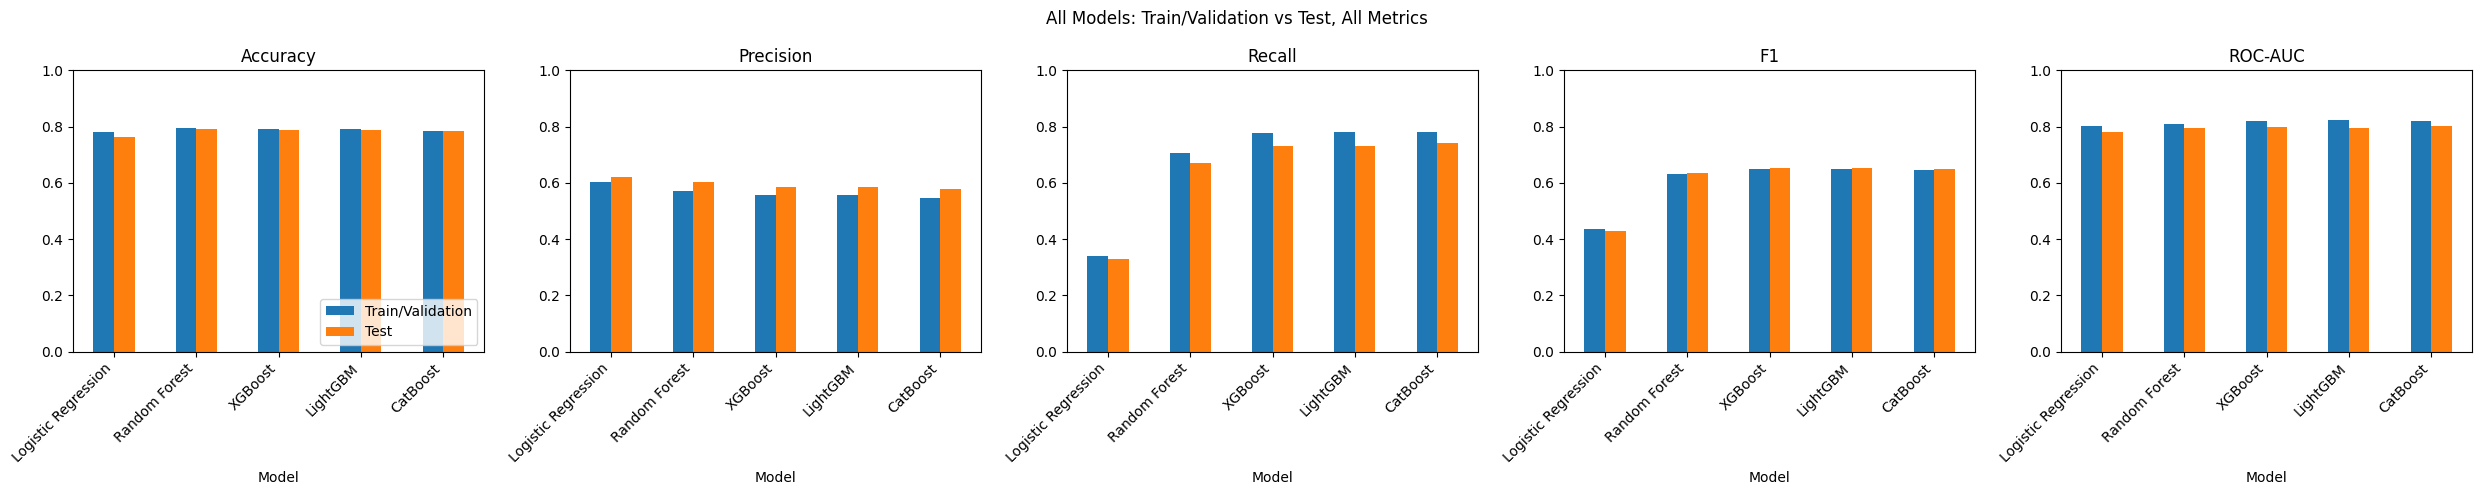

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, metric in zip(axes, metrics):
    combined_metric = pd.DataFrame({
        "Train/Validation": comparison_val_df[metric],
        "Test": comparison_test_df[metric]
    })
    combined_metric.plot(kind="bar", ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

axes[0].legend(loc="lower right")
plt.suptitle("All Models: Train/Validation vs Test, All Metrics")
plt.tight_layout()
plt.show()

## Conclusion

**Setup.** Five models were trained on the same cleaned feature set (12 raw features expanded to ~30 after encoding): Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost. Each was evaluated on a held-out validation split from `aug_train.csv` (3,832 rows) and then, separately, on the real `aug_test.csv` test set (2,129 rows) using the true labels from the answer-key dataset.

**Results summary (Validation → Test ROC-AUC):**

| Model | Val Accuracy | Val ROC-AUC | Test Accuracy | Test ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.780 | 0.802 | 0.764 | 0.780 |
| Random Forest | 0.795 | 0.811 | 0.791 | 0.796 |
| XGBoost | 0.790 | 0.819 | 0.788 | 0.799 |
| LightGBM | 0.791 | 0.823 | 0.788 | 0.796 |
| CatBoost | 0.785 | 0.821 | 0.784 | **0.801** |

**Key findings:**

- **CatBoost generalized best**, edging out XGBoost for the top Test ROC-AUC (0.801 vs 0.799), with all five models landing in a fairly tight 0.78–0.80 band on real test data.
- **Logistic Regression is the clear outlier on recall** (0.33 on validation, 0.33 on test) — it misses roughly two-thirds of the candidates who actually go on to change jobs. The tree-based models (Random Forest, XGBoost, LightGBM, CatBoost) all catch 67–78% of true job-changers, at some cost to precision. For an HR use case where the priority is *not missing* likely leavers, that recall gap makes Logistic Regression the weakest practical choice here, despite having a competitive ROC-AUC and the best raw accuracy/precision trade-off on paper.
- **The Validation → Test drop was modest and consistent across all models** (roughly 0.015–0.027 ROC-AUC), which is what you'd expect from ordinary sampling variation rather than a sign of serious overfitting. LightGBM had the largest gap (0.823 → 0.796); CatBoost and Random Forest were the most stable.
- **`city_development_index`, `company_size`, and `experience`** were consistently the top-ranked features across the tree-based models' importance rankings, aligning with the earlier EDA finding that missingness in `company_size`/`company_type` itself carried predictive signal (job-change rate roughly doubled for rows with missing company info).

**Recommendation:** CatBoost or XGBoost as the production candidate — both combine the strongest test-set ROC-AUC with the recall needed to actually flag at-risk candidates, and both showed a stable, unsurprising gap between validation and real test performance.

**Limitations / next steps:** no hyperparameter tuning was performed (all boosted models used the same fixed set of hyperparameters); the classification threshold was left at the default 0.5 rather than tuned for the HR team's actual cost trade-off between false positives (unnecessary retention outreach) and false negatives (an unflagged leaver); and SHAP values would give a more rigorous feature-attribution story than built-in importances.